<a href="https://colab.research.google.com/github/narendramanikala/-sales-dashboard/blob/main/customer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape: (200, 5)

Missing Values:

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


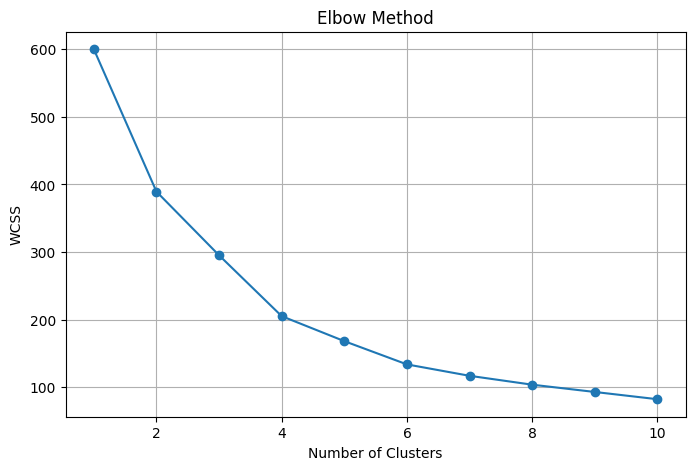


Silhouette Score: 0.417


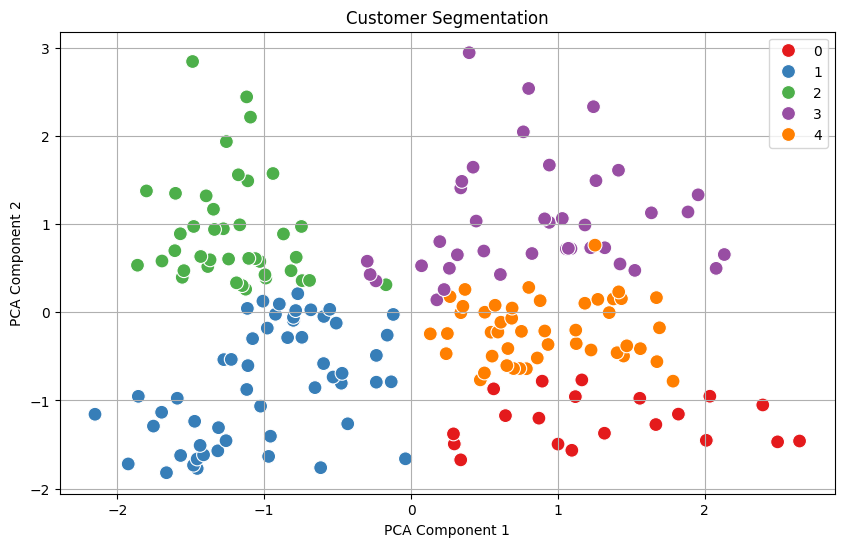


Cluster Summary:

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064

Output saved as Customer_Segmentation_Output.csv


In [3]:
# Customer Segmentation Project using K-Means Clustering
# 100% Working End-to-End Code
# Tools Used: Python, Pandas, Scikit-Learn, Matplotlib, Seaborn

# ============================
# STEP 1: Import Libraries
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ============================
# STEP 2: Load Dataset
# ============================

# Replace with your file name if needed
# Example CSV columns:
# CustomerID,Gender,Age,AnnualIncome,SpendingScore

df = pd.read_csv("/content/archive (2).zip")

# ============================
# STEP 3: Display Dataset Info
# ============================

print("First 5 Rows:\n")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nMissing Values:\n")
print(df.isnull().sum())

# ============================
# STEP 4: Data Preprocessing
# ============================

# Convert Gender to Numeric
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Select Features for Clustering
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Standardize Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================
# STEP 5: Find Optimal Clusters
# ============================

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

# ============================
# STEP 6: Apply K-Means
# ============================

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add Cluster Labels
df['Cluster'] = clusters

# ============================
# STEP 7: Evaluate Model
# ============================

score = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score:", round(score, 3))

# ============================
# STEP 8: PCA for Visualization
# ============================

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

df['PCA1'] = pca_data[:,0]
df['PCA2'] = pca_data[:,1]

# ============================
# STEP 9: Visualize Clusters
# ============================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.title("Customer Segmentation")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()

# ============================
# STEP 10: Cluster Analysis
# ============================

cluster_summary = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean()

print("\nCluster Summary:\n")
print(cluster_summary)

# ============================
# STEP 11: Save Output
# ============================

df.to_csv("Customer_Segmentation_Output.csv", index=False)

print("\nOutput saved as Customer_Segmentation_Output.csv")